<a href="https://colab.research.google.com/github/nalqnarik/House_Prices_Regression/blob/main/House_Price_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Գրադարանների և տվյալների ներմուծում

In [117]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv('/content/train.csv')

# First 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Տվյալների ուսումնասիրություն և նախապատրաստում

## Տվյալների ընդհանուր նկարագիր

In [6]:
# տողերի և սյուների քանակը
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1460
Number of columns: 81


In [7]:
# սյուների տվյալների տասակները
print(df.dtypes)

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


In [8]:
df.describe(include='all')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460,1460,1460,588,1452.000000,1460,1460,1460,1423,1423,1422,1423,1460.000000,1422,1460.000000,1460.000000,1460.000000,1460,1460,1460,1459,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460.000000,1460,1460.000000,770,1379,1379.000000,1379,1460.000000,1460.000000,1379,1379,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,5,3,25,9,8,5,8,NaN,NaN,NaN,NaN,6,8,15,16,3,NaN,4,5,6,4,4,4,6,NaN,6,NaN,NaN,NaN,6,5,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,7,NaN,5,6,NaN,3,NaN,NaN,5,5,3,NaN,NaN,NaN,NaN,NaN,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,NaN,NaN,NaN,NaN,Gable,CompShg,VinylSd,VinylSd,BrkFace,NaN,TA,TA,PConc,TA,TA,No,Unf,NaN,Unf,NaN,NaN,NaN,GasA,Ex,Y,SBrkr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TA,NaN,Typ,NaN,Gd,Attchd,NaN,Unf,NaN,NaN,TA,TA,Y,NaN,NaN,NaN,NaN,NaN,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,NaN,NaN,NaN,NaN,1141,1434,515,504,445,NaN,906,1282,647,649,1311,953,430,NaN,1256,NaN,NaN,NaN,1428,741,1365,1334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,735,NaN,1360,NaN,380,870,NaN,605,NaN,NaN,1311,1326,1340,NaN,NaN,NaN,NaN,NaN,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.099315,5.575342,1971.267808,1984.865753,NaN,NaN,NaN,NaN,NaN,103.685262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,443.639726,NaN,46.549315,567.240411,1057.429452,NaN,NaN,NaN,NaN,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,NaN,6.517808,NaN,0.613014,NaN,NaN,1978.506164,NaN,1.767123,472.980137,NaN,NaN,NaN,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.382997,1.112799,30.202904,20.645407,NaN,NaN,NaN,NaN,NaN,181.066207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,456.098091,NaN,161.319273,441.866955,438.705324,NaN,NaN,NaN,NaN,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,NaN,1.625393,NaN,0.644666,NaN,NaN,24.689725,NaN,0.747315,213.804841,NaN,NaN,NaN,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1872.000000,1950.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,2.000000,NaN,0.000000,NaN,NaN,1900.000000,N

## Բացակայող արժեքների ուսումնասիրություն

In [9]:
# բացակայող արժեքների քանակը ըստ սյուների
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [10]:
# թվային և որակական հատկանիշների առանձնացում
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 38
Categorical columns: 43


In [11]:
# թվային սյուների համար բացակայող արժեքները կլրացնենք այդ սյան միջին արժեքով
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [12]:
# որակական հատկանիշների համար բացակայող արժեքները կլրացնենք այդ սյան մոդով
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
# կարող ենք տեսնել, որ այլևս բացակայող արժեքներ չկան
print(df.isnull().sum().sum())

0


## Կորելացիոն կապը SalePrice՝ տան գնի հետ

In [14]:
# ստուգենք կորելացիոն կապը, գտնենք կորելացիայի գործակիցները
corr_matrix = df.select_dtypes(include=np.number).corr()
sale_corr = corr_matrix["SalePrice"].sort_values(ascending=False)
sale_corr.head(15)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


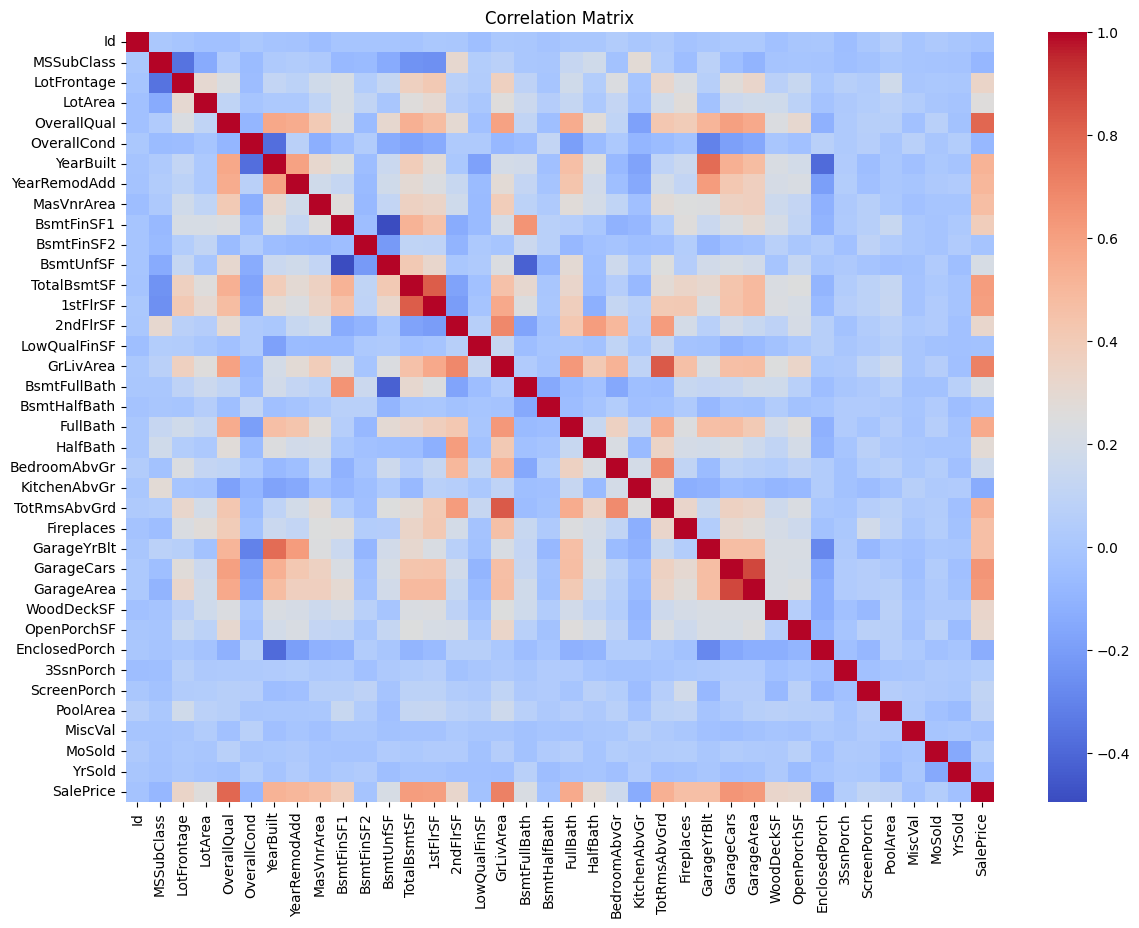

In [15]:
# կարող ենք տեսնել կորելացիոն կապը գրաֆիկի միջոցով
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

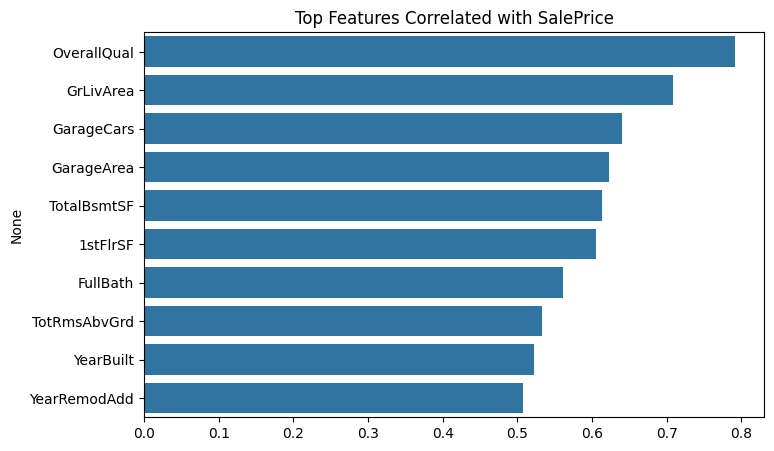

In [16]:
# 10 ամենաուժեղ կորելացիոն կապով հատկանիշները
top_corr = sale_corr[1:11]

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with SalePrice")
plt.show()

## Ծայրահեղ արժեքների հետազոտություն

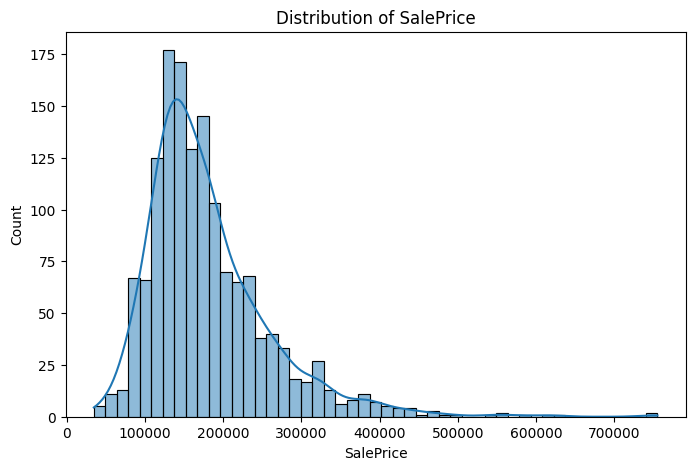

In [17]:
# SalPrice-ի բաշխումը
plt.figure(figsize=(8,5))

sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.title("Distribution of SalePrice")
plt.show()

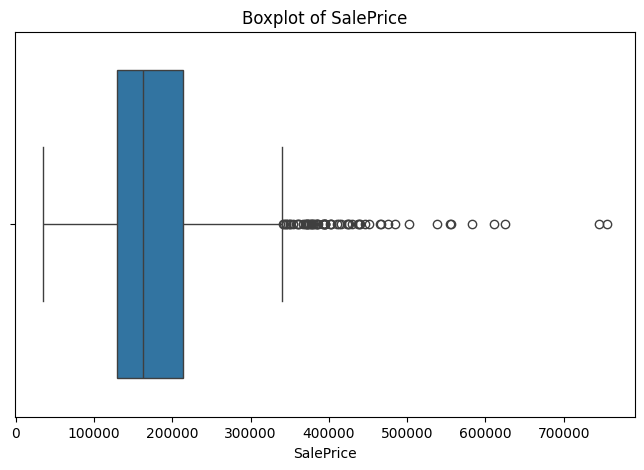

In [18]:
# SalePrice boxplot-ի միջոցով կարող ենք տեսնել ծայրահեղ արժեքները
plt.figure(figsize=(8,5))

sns.boxplot(x=df["SalePrice"])

plt.title("Boxplot of SalePrice")
plt.show()

In [19]:
# Ծայրահեղ արժեքների հեռացում
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)
IQR = Q3 - Q1
df = df.drop(
    df[
    (df["SalePrice"] < (Q1 - 1.5 * IQR)) | (df["SalePrice"] > (Q3 + 1.5 * IQR))
    ].index
    )


In [20]:
print(df.shape)

(1399, 81)


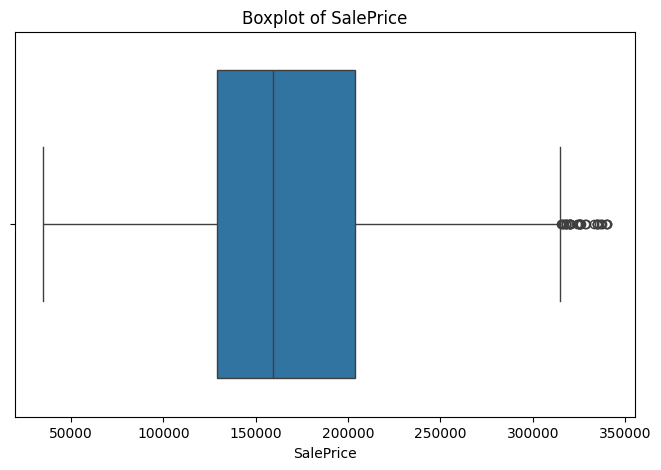

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["SalePrice"])

plt.title("Boxplot of SalePrice")
plt.show()

## Feature engineering

In [22]:
# նոր հատկանիշի սահմանում
df["TotalSF"] = (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

In [23]:
# նոր հատկանիշի սահմանում
df["HouseAge"] = (
    df["YrSold"] -
    df["YearBuilt"]
)

In [24]:
df[["TotalSF", "HouseAge"]].head()

,TotalSF,HouseAge
0,2566,5
1,2524,31
2,2706,7
3,2473,91
4,3343,8


In [25]:
categorical_cols = df.select_dtypes(include=['object']).columns

print("Number of categorical columns:", len(categorical_cols))
print(categorical_cols)

Number of categorical columns: 43
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [26]:
# որակական սյուների թվային վերափոխում one-hot encoding-ով
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [27]:
print(df.shape)
df.head()

(1399, 248)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,TotalSF,HouseAge,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,Fence_GdWo,Fence_MnPrv,Fence_MnWw,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500,2566,5,False,Fals

# Մոդելի ուսուցում

## Տվյալների նախապատրաստում

In [28]:
# բացատրվող փոփոխական
y = df["SalePrice"]

In [29]:
# բացտրող փոփոխականներ
X = df.drop("SalePrice", axis=1)

In [30]:
print(X.shape)
print(y.shape)

(1399, 247)
(1399,)


In [31]:
# տվյալների բաժանում
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1119, 247)
Test shape: (280, 247)


In [33]:
scaler = StandardScaler()

In [34]:
# տվյալների նորմավորում
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1119, 247)
(280, 247)


## Linear Regression

In [36]:
# գծային մոդելը
lr_model = LinearRegression()

In [37]:
# տվյալների ուսուցում
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [38]:
# ազատ անդամի արժեքը
print("Intercept:")
print(lr_model.intercept_)

Intercept:
171335.21894548708


In [39]:
# հատկանիշների գործակիցները
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coef_df

,Feature,Coefficient
0,Id,-787.099641
1,MSSubClass,-1784.426870
2,LotFrontage,608.907926
3,LotArea,5560.932011
4,OverallQual,7768.159025
...,...,...
242,SaleCondition_AdjLand,1140.132531
243,SaleCondition_Alloca,-113.751850
244,SaleCondition_Family,82.104105
245,SaleCondition_Normal,2942.600330


In [40]:
# հատկանիշների գործակիցները նվազման կարգով ըստ բացարձակ արժեքի
coef_df["AbsCoef"] = abs(coef_df["Coefficient"])

coef_df.sort_values(
    by="AbsCoef",
    ascending=False
).head(15)

,Feature,Coefficient,AbsCoef
113,RoofMatl_CompShg,66405.555512,66405.555512
117,RoofMatl_Tar&Grv,46961.600844,46961.600844
119,RoofMatl_WdShngl,31215.206662,31215.206662
118,RoofMatl_WdShake,25632.748117,25632.748117
115,RoofMatl_Metal,18401.456844,18401.456844
16,GrLivArea,12101.796695,12101.796695
93,Condition2_PosN,-10885.154483,10885.154483
14,2ndFlrSF,10708.311241,10708.311241
41,MSZoning_RL,9830.009808,9830.009808
37,TotalSF,9773.916049,9773.916049


In [41]:
# չուսուցված տվյալների կանխագուշակում
y_pred_lr = lr_model.predict(X_test_scaled)

In [42]:
# իրական և կանխագուշակված տվյալների համեմատություն
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lr
})

results.head(10)

,Actual,Predicted
703,140000,124704.679672
656,145500,141330.455073
119,163990,175531.937810
502,140000,156591.745805
243,120000,127689.968386
763,337000,299589.883269
216,210000,210285.558062
913,145000,173984.668713
985,125000,122950.112206
503,289000,271340.484602


In [43]:
# միջին բացարձակ սխալանք
mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

print("MAE:", mae_lr)

MAE: 17300.971727255717


In [44]:
# միջին քառակուսային սխալանք
mse_lr = mean_squared_error(
    y_test,
    y_pred_lr
)

print("MSE:", mse_lr)

MSE: 3014157151.858952


In [45]:
# ստանդարտ շեղումը
rmse_lr = np.sqrt(mse_lr)
print("RMSE:", rmse_lr)

RMSE: 54901.34016450739


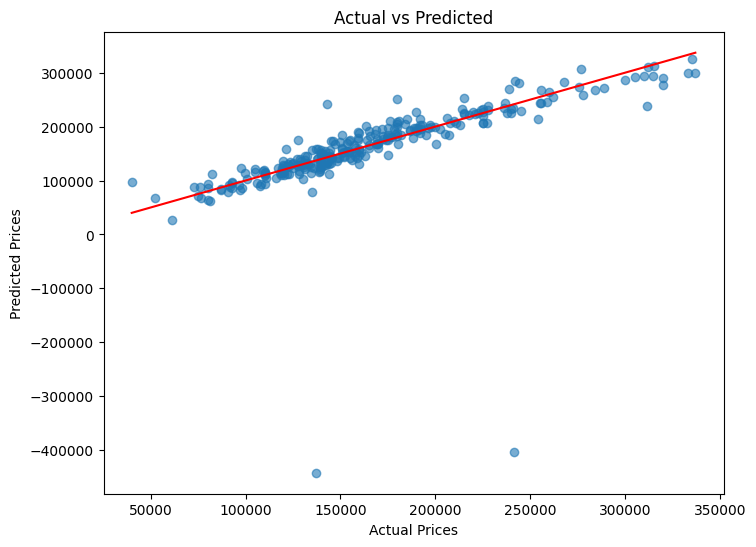

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")

plt.show()

In [47]:
# մնացորդները
residuals_lr = y_test - y_pred_lr

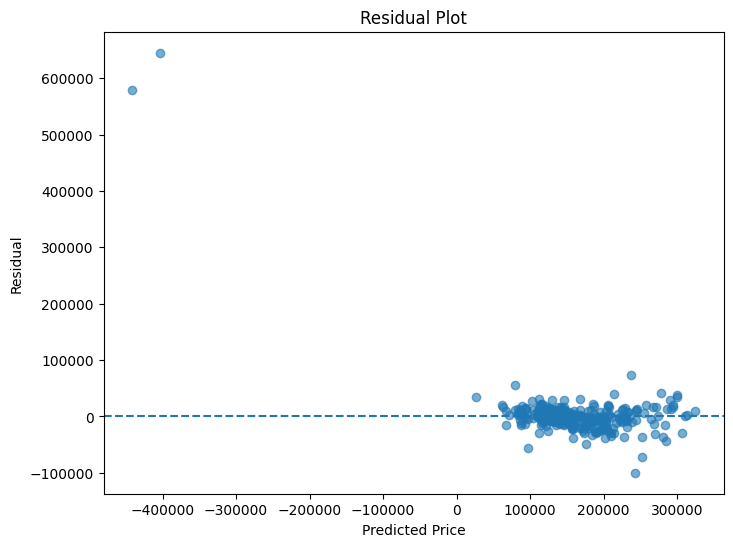

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_lr,
    residuals_lr,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [49]:
# 10 ամենաազդեցիկ հատկանիշներն ըստ բացարձակ գործակցի արժեքի
top_features = coef_df.sort_values(
    by="AbsCoef",
    ascending=False
).head(10)

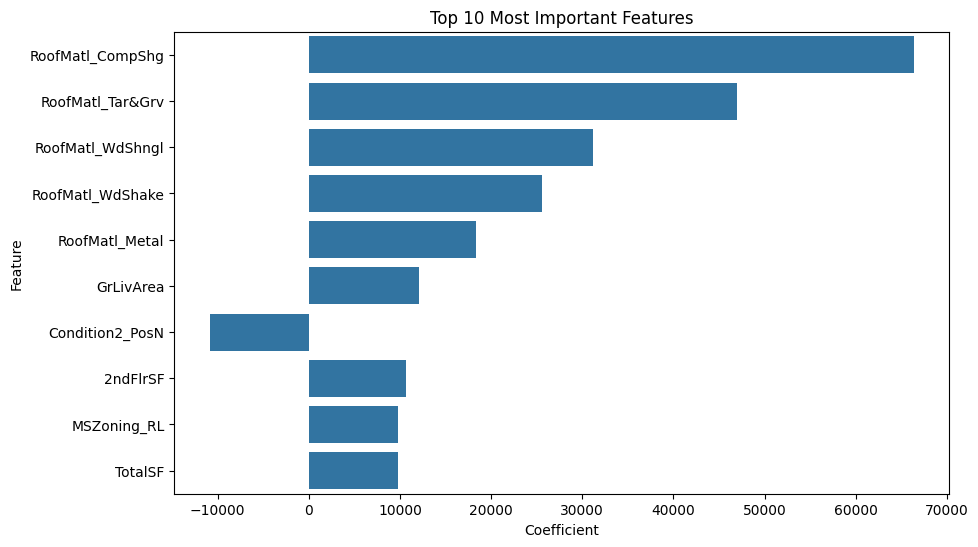

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.show()

In [51]:
# գծային ռեգրեսիայի սխալանքները
print("Linear Regression Results")
print("-" * 30)
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)

Linear Regression Results
------------------------------
MAE : 17300.971727255717
MSE : 3014157151.858952
RMSE: 54901.34016450739


## Lasso Regression

In [52]:
lasso = Lasso(
    alpha=100,
    random_state=42
)

In [53]:
lasso.fit(
    X_train_scaled,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.573e+09, tolerance: 4.007e+08
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=100, random_state=42)

In [54]:
y_pred_lasso = lasso.predict(
    X_test_scaled
)

In [55]:
# միջին բացարձակ սխալանք
mae_lasso = mean_absolute_error(
    y_test,
    y_pred_lasso
)

print("MAE:", mae_lasso)

MAE: 16005.295918510175


In [56]:
# միջին քառակուսային սխալանք
mse_lasso = mean_squared_error(
    y_test,
    y_pred_lasso
)

print("MSE:", mse_lasso)

MSE: 1951216507.2035685


In [57]:
# ստանդարտ շեղում
rmse_lasso = np.sqrt(mse_lasso)

print("RMSE:", rmse_lasso)

RMSE: 44172.576415730706


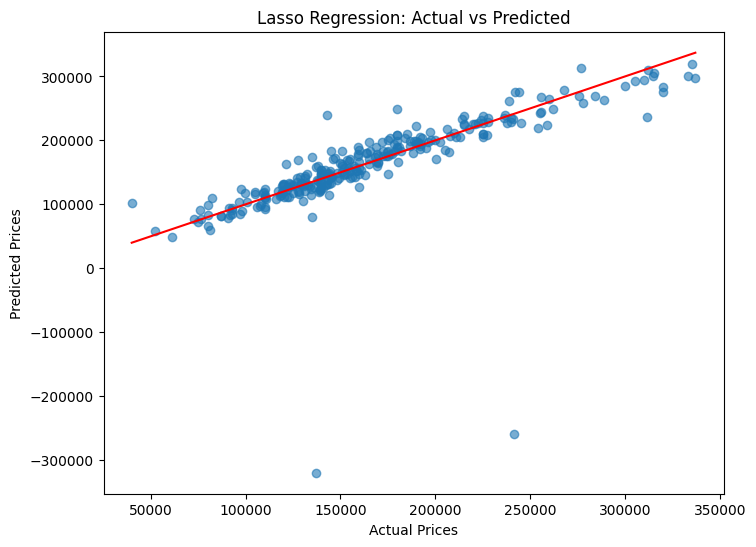

In [58]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_lasso,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Lasso Regression: Actual vs Predicted")

plt.show()

In [59]:
# մնացորդները
residuals_lasso = y_test - y_pred_lasso

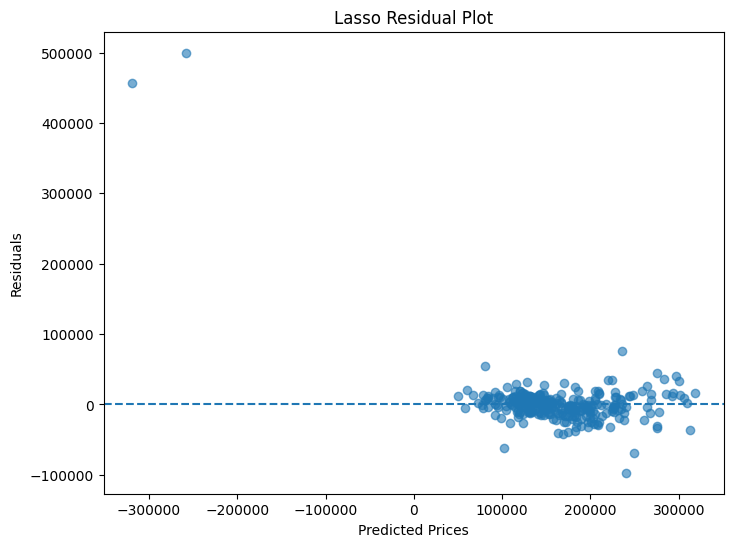

In [60]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_lasso,
    residuals_lasso,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.title("Lasso Residual Plot")

plt.show()

## KNN

In [61]:
# գտնենք լավագույն k որի դեպքում կուենանք ամենափոքր RMSE, ընտրենք k-ն 1-ից 50
k_values = range(1, 50)

rmse_values = []

In [62]:
# 1-ից 50 բոլոր k-երի համար սահմանենք մոդելը, ուսուցանենք, կանխատեսենք և հաշվենք RMSE
for k in k_values:

    model = KNeighborsRegressor(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    pred = model.predict(
        X_test_scaled
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    rmse_values.append(rmse)

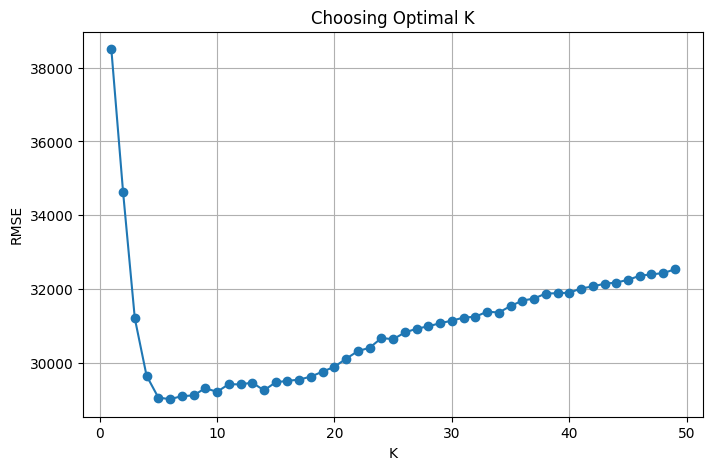

In [63]:
# գրաֆիկում կարող ենք տեսնել ամեն k-ի համար RMSE
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    rmse_values,
    marker='o'
)

plt.xlabel("K")
plt.ylabel("RMSE")

plt.title("Choosing Optimal K")
plt.grid()

plt.show()

In [64]:
# նաև գրաֆիկից երևում է որ լավագույն k=6
best_k = k_values[np.argmin(rmse_values)]

print("Best K =", best_k)

Best K = 6


In [65]:
# մոդելի սահմանումը, best_k դեպքում
knn_model = KNeighborsRegressor(n_neighbors=best_k)

In [66]:
# տվյալների ուսուցում
knn_model.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=6)

In [67]:
# չուսուցված տվյալների կանխագուշակում
y_pred_knn = knn_model.predict(X_test_scaled)

In [68]:
# միջին բացարձակ սխալանք
mae_knn = mean_absolute_error(
    y_test,
    y_pred_knn
)

print("MAE:", mae_knn)

MAE: 20555.74404761905


In [69]:
# միջին քառակուսային սխալանք
mse_knn = mean_squared_error(
    y_test,
    y_pred_knn
)

print("MSE:", mse_knn)

MSE: 841805354.0103174


In [70]:
# ստանդարտ շեղում
rmse_knn = np.sqrt(mse_knn)

print("RMSE:", rmse_knn)

RMSE: 29013.88209134237


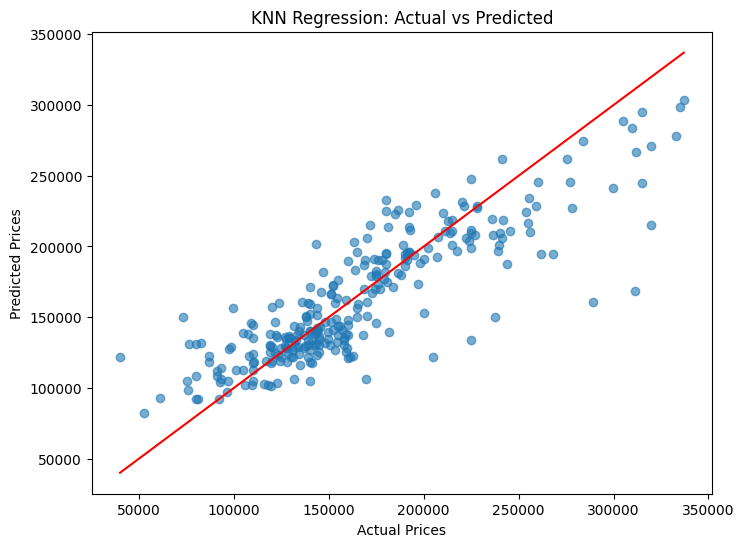

In [71]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_knn,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("KNN Regression: Actual vs Predicted")

plt.show()

In [72]:
# մնացորդները
residuals_knn = y_test - y_pred_knn

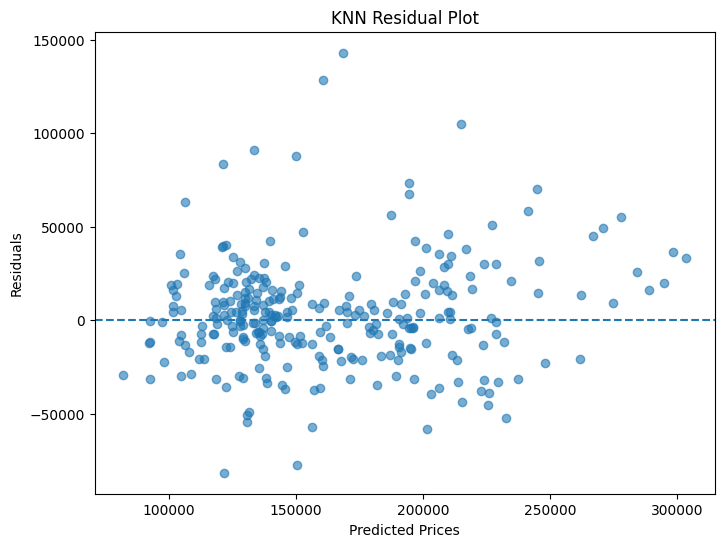

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_knn,
    residuals_knn,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.title("KNN Residual Plot")

plt.show()

## Կշռված KNN

In [74]:
# սահմանենք կշիռներով մոդելը, որպես կշիռ վերցնելով հեռավորությունը
knn_weighted = KNeighborsRegressor(
    n_neighbors=best_k,
    weights='distance'
    )

In [75]:
# ուսուցանենք մոդելը
knn_weighted.fit(
    X_train_scaled,
    y_train
)

KNeighborsRegressor(n_neighbors=6, weights='distance')

In [76]:
# չուսուցանված տվյալների կանխատեսում
y_pred_weighted = knn_weighted.predict(
    X_test_scaled
)

In [77]:
# միջին բացարձակ սխալանք
mae_weighted = mean_absolute_error(
    y_test,
    y_pred_weighted
)
print("MAE:", mae_weighted)

MAE: 20306.842374977845


In [78]:
# միջին քառակուսային սխալանք
mse_weighted = mean_squared_error(
    y_test,
    y_pred_weighted
)
print("MSE:", mse_weighted)

MSE: 826893887.2055464


In [79]:
# ստանդարտ շեղում
rmse_weighted = np.sqrt(mse_weighted)
print("RMSE:", rmse_weighted)

RMSE: 28755.762678210194


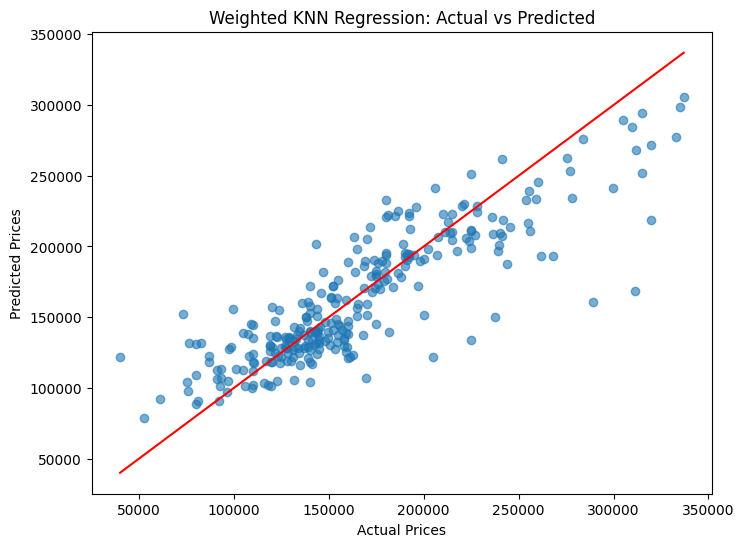

In [80]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_weighted,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Weighted KNN Regression: Actual vs Predicted")

plt.show()

In [81]:
# մնացորդները
residuals_weighted = y_test - y_pred_weighted

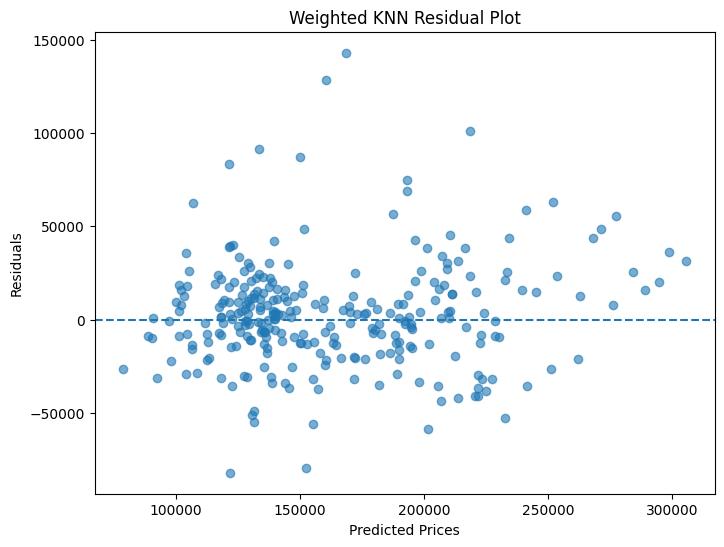

In [82]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_weighted,
    residuals_weighted,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.title("Weighted KNN Residual Plot")

plt.show()

## Որոշման ծառեր

In [123]:
# մոդելի սահմանում
tree_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [124]:
# մոդելի ուսուցում
tree_model.fit(
    X_train,
    y_train
)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [125]:
# չուսուցանված տվյալների կանխատեսում
y_pred_tree = tree_model.predict(
    X_test
)

In [127]:
# միջին բացարձակ սխալանք
mae_tree = mean_absolute_error(
    y_test,
    y_pred_tree
)
print("MAE:", mae_tree)

MAE: 20446.990377190272


In [128]:
# միջին քառակուսային սխալանք
mse_tree = mean_squared_error(
    y_test,
    y_pred_tree
)
print("MSE:", mse_tree)

MSE: 832717276.6472229


In [130]:
# միջին քառակուսային սխալանք
rmse_tree = np.sqrt(mse_tree)
print("RMSE:", rmse_tree)

RMSE: 28856.841071871033


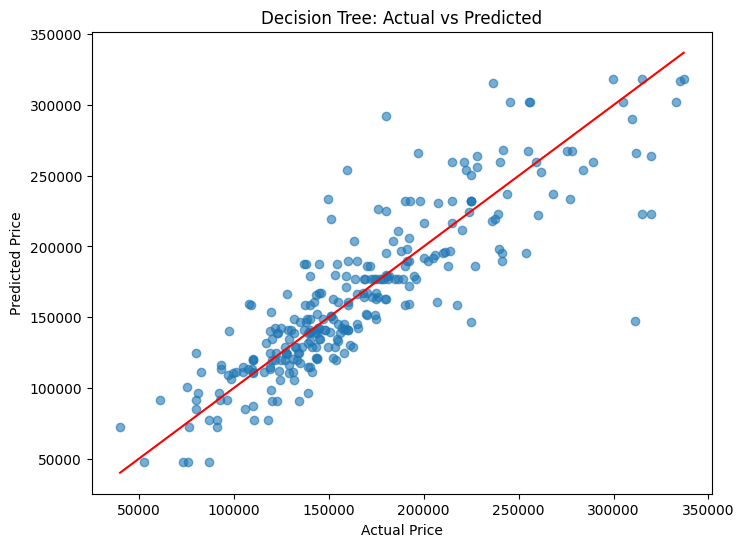

In [90]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_tree,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

In [112]:
# մնացորդները
residuals_tree = y_test - y_pred_tree

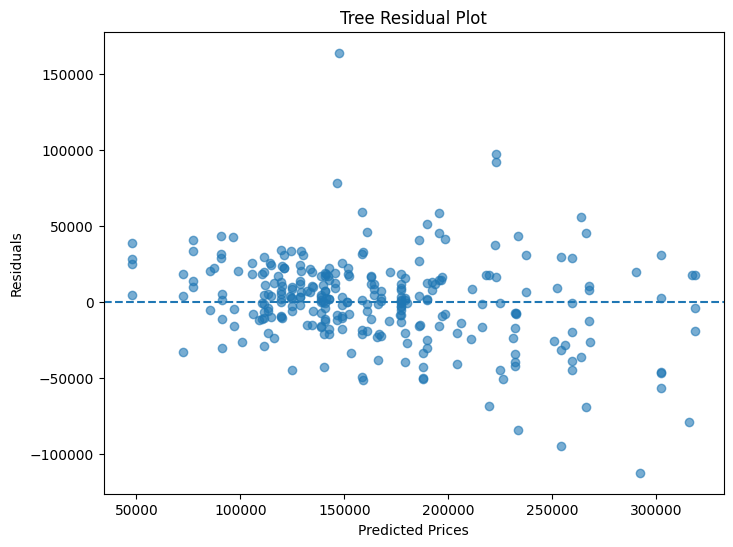

In [113]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_tree,
    residuals_tree,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.title("Tree Residual Plot")

plt.show()

In [131]:
# Հատկանիշների կարևորությունը
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})

In [132]:
# 10 ամենակարևոր հատկանիշները
top_features = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

top_features

,Feature,Importance
4,OverallQual,0.535388
37,TotalSF,0.301654
11,BsmtUnfSF,0.014325
3,LotArea,0.013688
213,GarageType_Detchd,0.010297
26,GarageCars,0.009994
9,BsmtFinSF1,0.009424
6,YearBuilt,0.009170
27,GarageArea,0.007471
13,1stFlrSF,0.007384


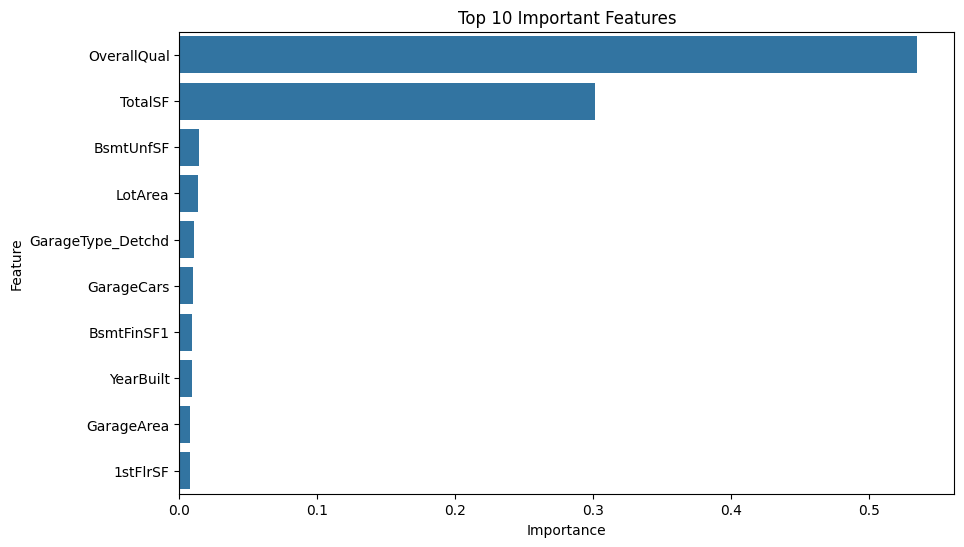

In [133]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

## Random Forest

In [134]:
# մոդելի սահմանում
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [135]:
# մոդելի ուսուցանում
rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [136]:
# չուսուցանված տվյալների կանխատեսում
y_pred_rf = rf_model.predict(
    X_test
)

In [137]:
# միջին բացարձակ սխալանք
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)
print("MAE:", mae_rf)

MAE: 14416.908000000001


In [138]:
# միջին քառակուսային սխալանք
mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)
print("MSE:", mse_rf)

MSE: 432986950.48333716


In [139]:
# ստանդարտ շեղում
rmse_rf = np.sqrt(mse_rf)
print("RMSE:", rmse_rf)

RMSE: 20808.33848444746


In [140]:
# կարևոր հատկանիշները
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

In [141]:
top_rf = rf_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

top_rf

,Feature,Importance
37,TotalSF,0.434531
4,OverallQual,0.314738
3,LotArea,0.015424
27,GarageArea,0.015076
16,GrLivArea,0.014141
38,HouseAge,0.013209
6,YearBuilt,0.012864
11,BsmtUnfSF,0.012432
7,YearRemodAdd,0.010364
153,ExterQual_TA,0.009995


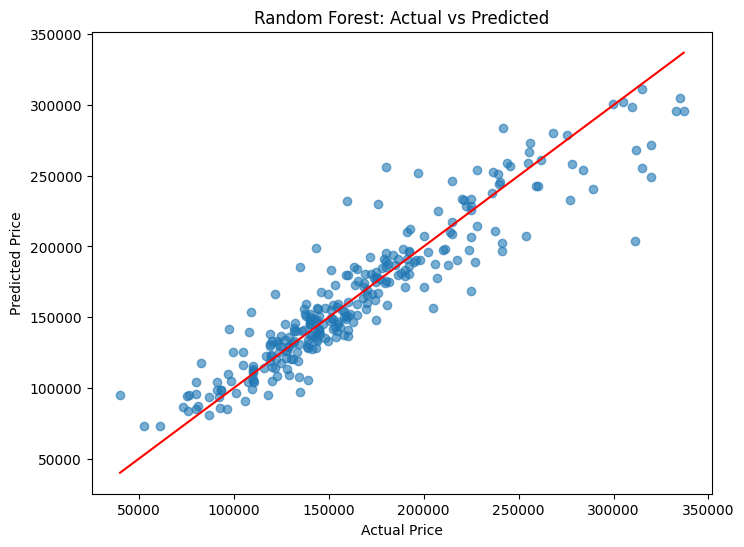

In [142]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [143]:
# մնացորդները
residuals_rf = y_test - y_pred_rf

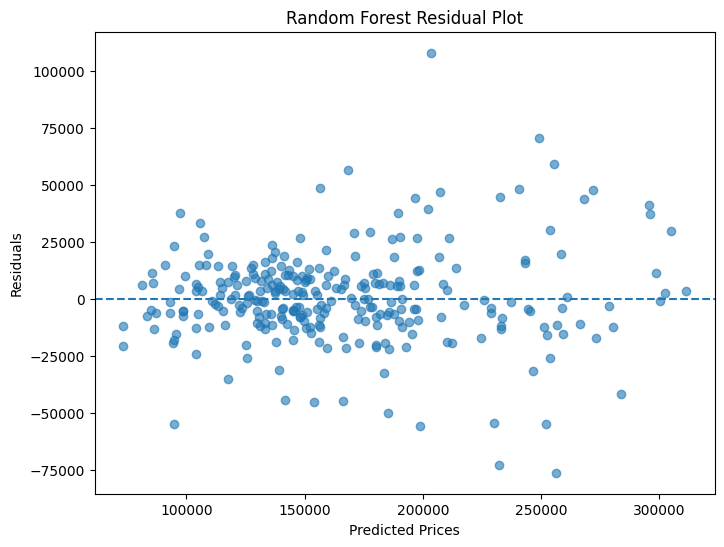

In [144]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_rf,
    residuals_rf,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.title("Random Forest Residual Plot")

plt.show()

## Boosting

In [145]:
# մոդելի սահմանում
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [146]:
# մոդելի ուսուցանում
gbr.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [147]:
# չուսուցանված տվյալների կանխատեսում
y_pred_gbr = gbr.predict(X_test)

In [148]:
# միջին բացարձակ սխալանք
mae_gbr = mean_absolute_error(
    y_test,
    y_pred_gbr
)
print("MAE:", mae_gbr)

MAE: 13309.163058388913


In [149]:
# միջին քառակուսային սխալանք
mse_gbr = mean_squared_error(
    y_test,
    y_pred_gbr
)
print("MSE:", mse_gbr)

MSE: 385222732.89835435


In [150]:
# ստանդարտ շեղում
rmse_gbr = np.sqrt(mse_gbr)
print("RMSE:", rmse_gbr)

RMSE: 19627.09180949522


In [152]:
# կարևոր հատկանիշները
gbr_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gbr.feature_importances_
})

In [153]:
top_gbr = gbr_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

top_gbr

,Feature,Importance
37,TotalSF,0.414367
4,OverallQual,0.313687
3,LotArea,0.018574
7,YearRemodAdd,0.017828
153,ExterQual_TA,0.016849
26,GarageCars,0.016658
38,HouseAge,0.016210
24,Fireplaces,0.015611
16,GrLivArea,0.013994
215,GarageFinish_Unf,0.013016


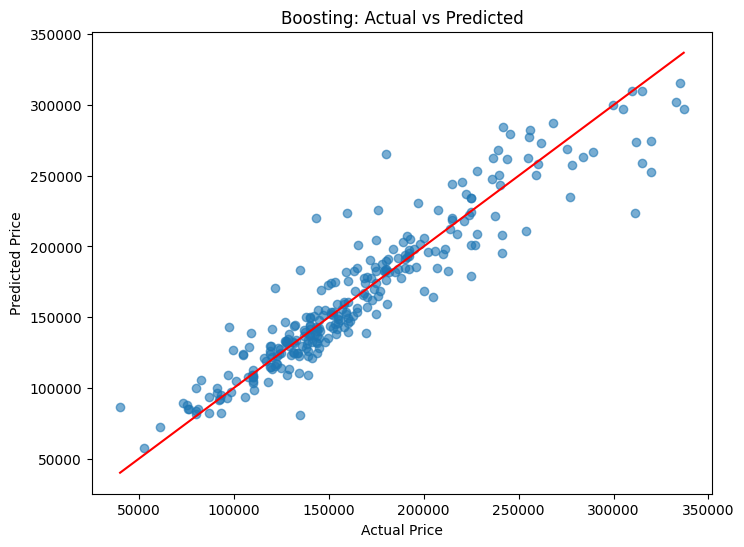

In [154]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_gbr,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Boosting: Actual vs Predicted")

plt.show()

In [155]:
# մնացորդները
residuals_gbr = y_test - y_pred_gbr

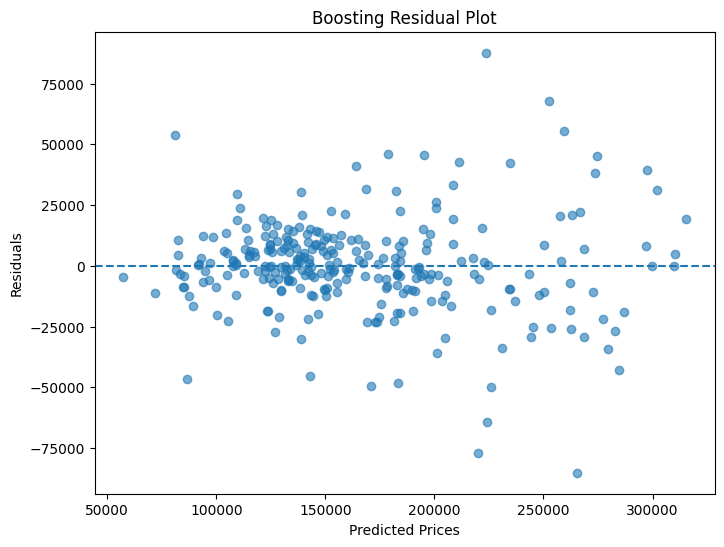

In [156]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_gbr,
    residuals_gbr,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.title("Boosting Residual Plot")

plt.show()

## Մոդելների համեմատություն




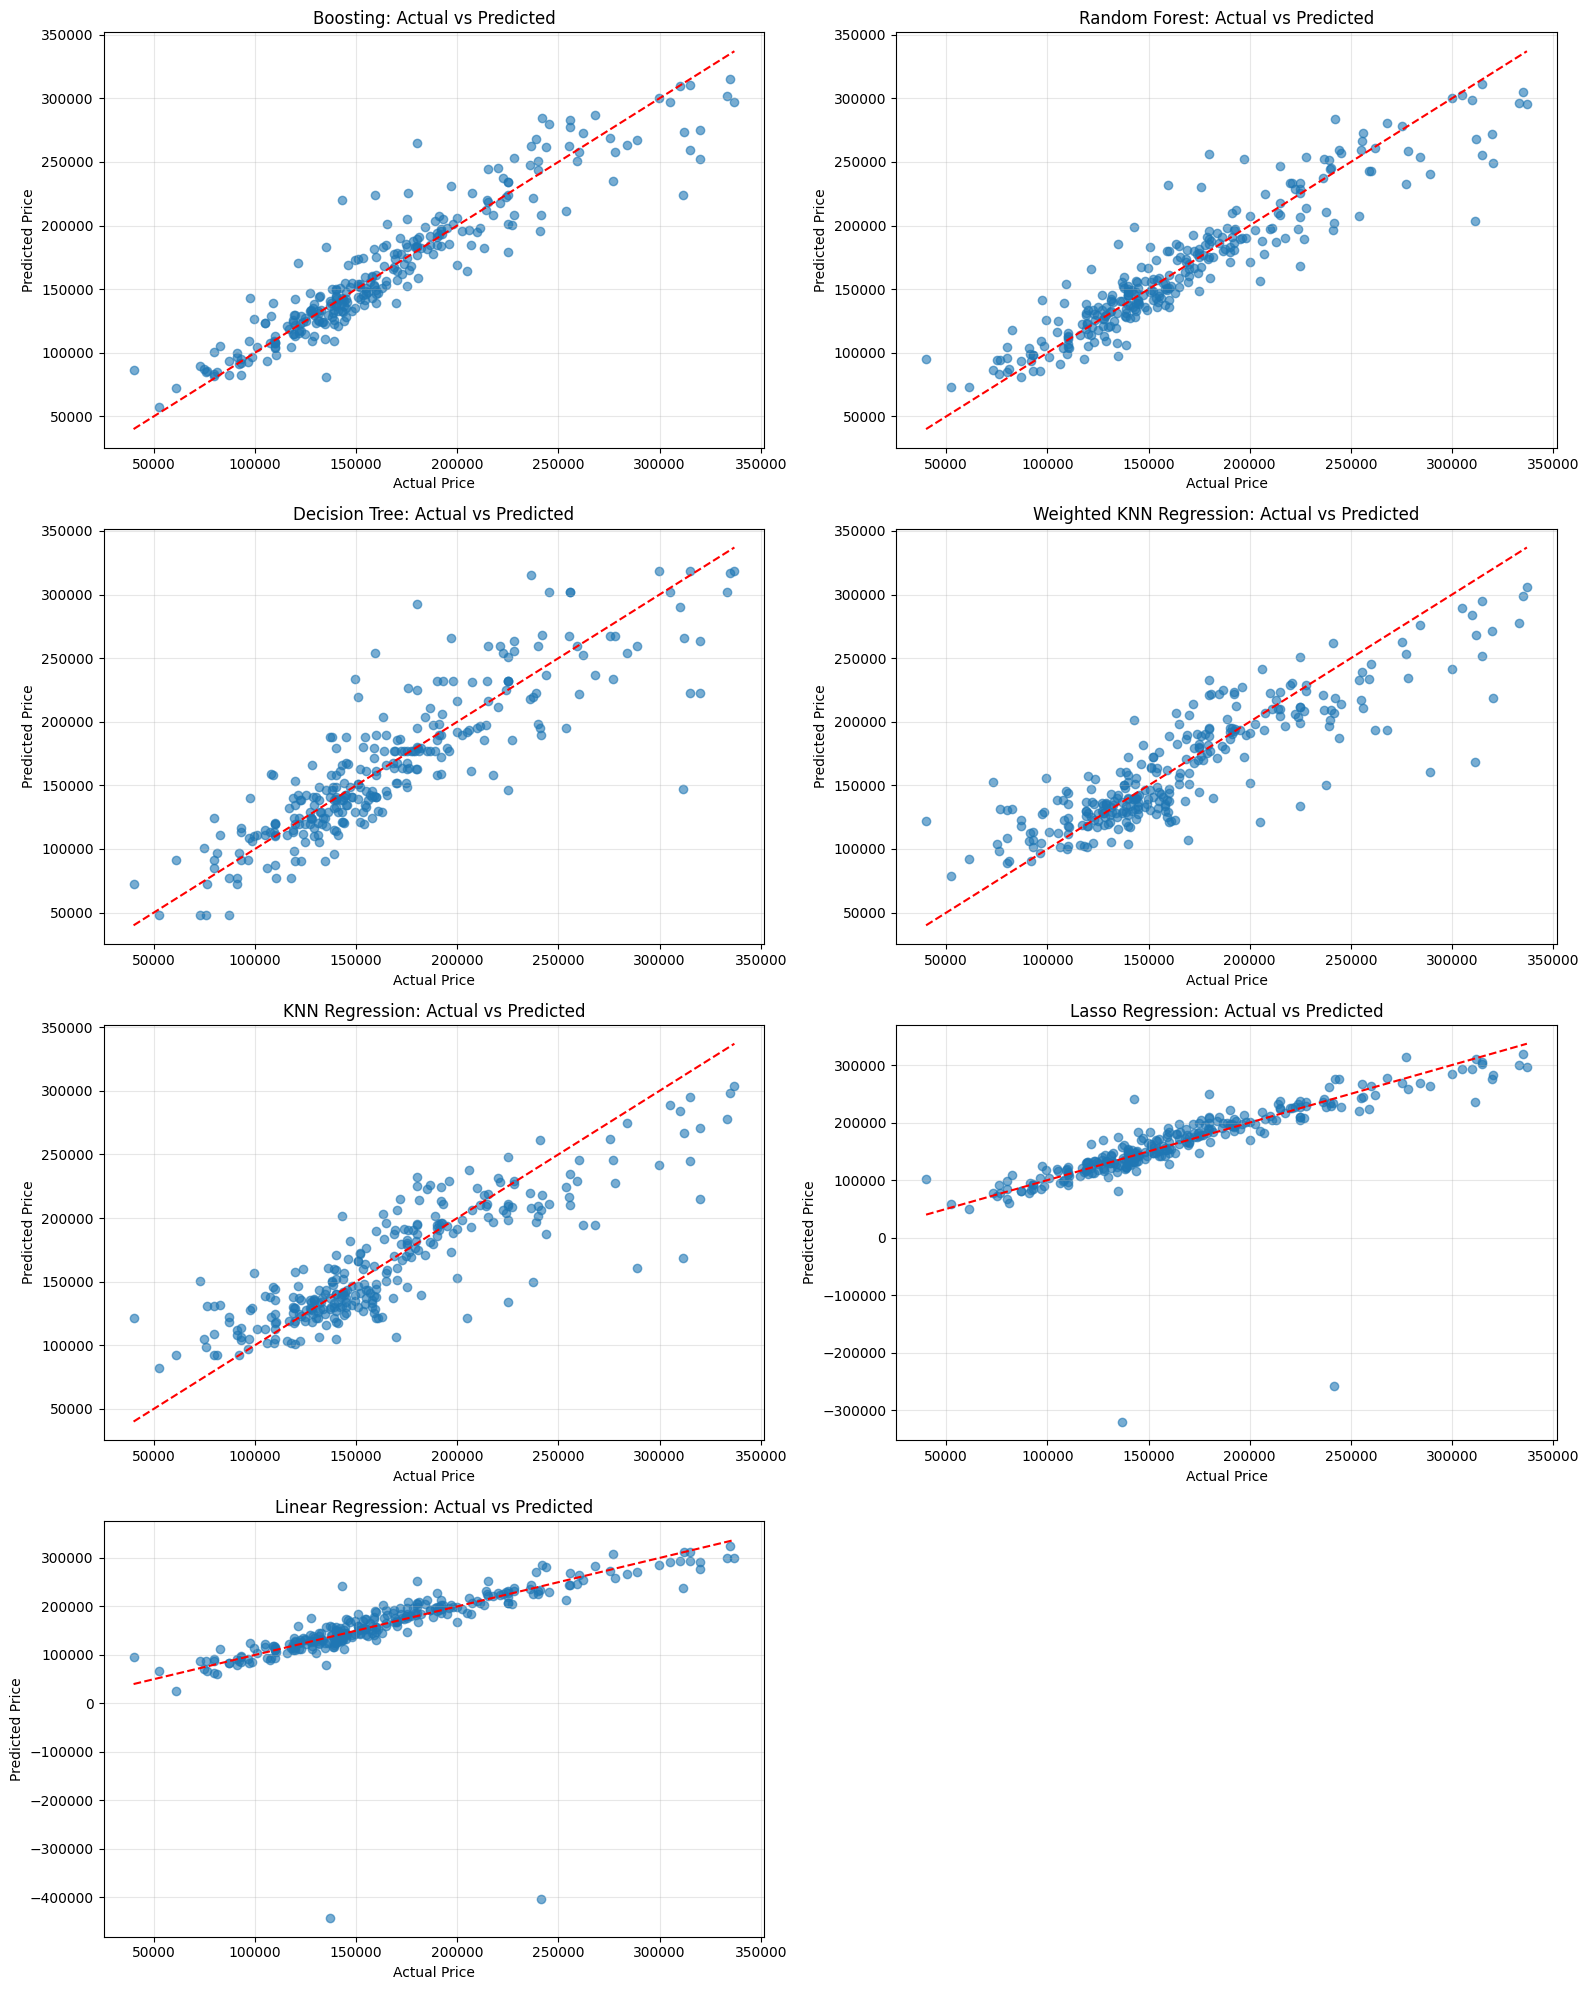

In [160]:
models = [
    ("Boosting", y_pred_gbr),
    ("Random Forest", y_pred_rf),
    ("Decision Tree", y_pred_tree),
    ("Weighted KNN Regression", y_pred_weighted),
    ("KNN Regression", y_pred_knn),
    ("Lasso Regression", y_pred_lasso),
    ("Linear Regression", y_pred_lr)
]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))

axes = axes.flatten()

for i, (title, y_pred) in enumerate(models):
    ax = axes[i]

    ax.scatter(y_test, y_pred, alpha=0.6)

    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r', linestyle='--'
    )

    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title(f"{title}: Actual vs Predicted")
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [157]:
# մեթոդների համեմատություն
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Lasso Regression",
        "KNN Regression",
        "Weighted KNN",
        "Decision Tree",
        "Random Forest",
        "Boosting"
    ],
    "MAE": [
        mae_lr,
        mae_lasso,
        mae_knn,
        mae_weighted,
        mae_tree,
        mae_rf,
        mae_gbr
    ],
    "MSE": [
        mse_lr,
        mse_lasso,
        mse_knn,
        mse_weighted,
        mse_tree,
        mse_rf,
        mse_gbr
    ],
    "RMSE": [
        rmse_lr,
        rmse_lasso,
        rmse_knn,
        rmse_weighted,
        rmse_tree,
        rmse_rf,
        rmse_gbr
    ]
})

comparison

,Model,MAE,MSE,RMSE
0,Linear Regression,17300.971727,3.014157e+09,54901.340165
1,Lasso Regression,16005.295919,1.951217e+09,44172.576416
2,KNN Regression,20555.744048,8.418054e+08,29013.882091
3,Weighted KNN,20306.842375,8.268939e+08,28755.762678
4,Decision Tree,20446.990377,8.327173e+08,28856.841072
5,Random Forest,14416.908000,4.329870e+08,20808.338484
6,Boosting,13309.163058,3.852227e+08,19627.091809


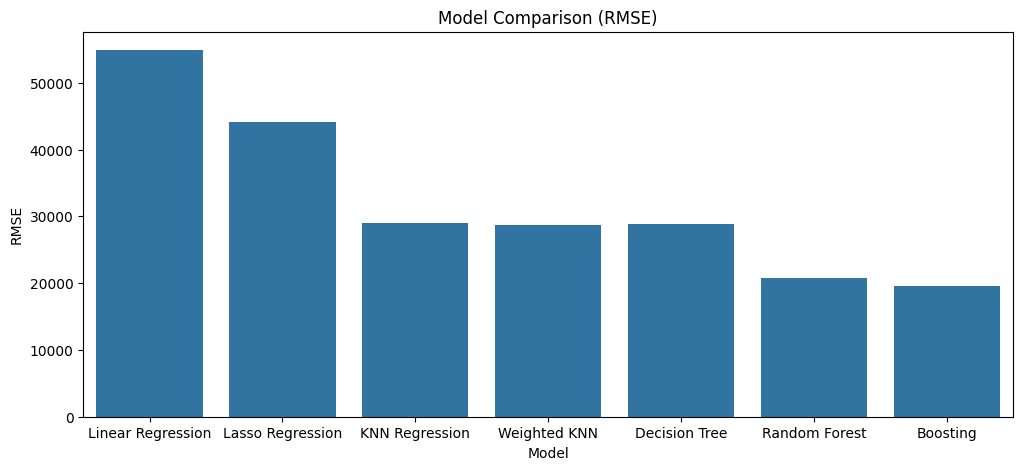

In [158]:
# barplot-ի միջոցով լավ երևում է, թե որ մեթոդն է այս դեպքում ավելի էֆֆեկտիվ և ունի ավելի փոքր սխալանքներ
plt.figure(figsize=(12,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison (RMSE)")
plt.show()

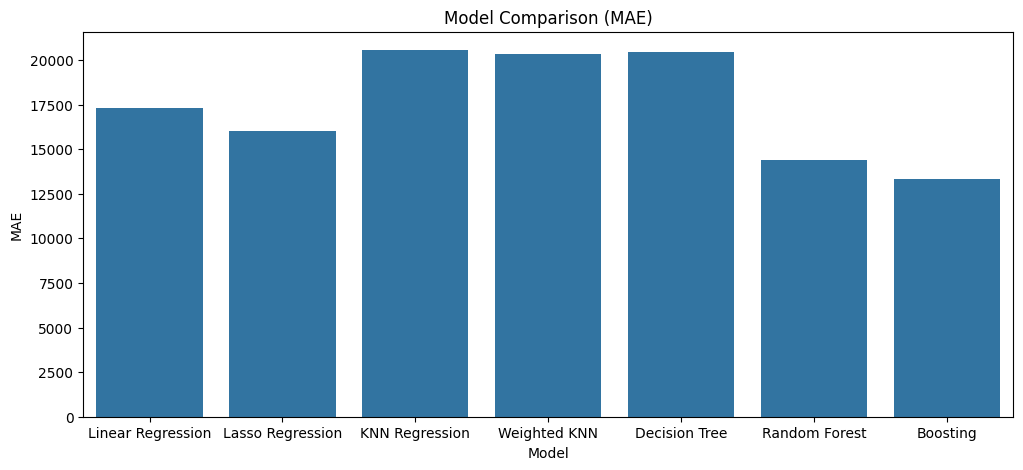

In [159]:
# barplot-ի միջոցով լավ երևում է, թե որ մեթոդն է այս դեպքում ավելի էֆֆեկտիվ և ունի ավելի փոքր սխալանքներ
plt.figure(figsize=(12,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="MAE"
)

plt.title("Model Comparison (MAE)")
plt.show()